# YOLOv11m Training — Kaggle Optimised

### Improvements over the baseline
| Area | Change | Why |
|------|--------|-----|
| Mixed precision | `amp=True` | ~2× faster on T4/P100, lower VRAM |
| Optimizer | `AdamW` + cosine LR | Better generalisation than SGD on small datasets |
| Grad accumulation | `nbs=64` with `batch=16` | Effective batch = 64 — stabilises training |
| Warmup | `warmup_epochs=5` | Prevents early divergence |
| Label smoothing | `label_smoothing=0.1` | Reduces overconfidence |
| Weight decay | `weight_decay=0.0005` | L2 regularisation |
| Dataset cache | `cache='disk'` | Kaggle SSD ≈ 3× faster data loading |
| Augmentation | Stronger mix (erasing, bigger mixup/copy-paste) | More robust features |
| Post-training | TTA validation + ONNX export | Better eval + deployment ready |
| Patience | 50 epochs | Gives cosine LR room to recover |

All outputs are saved under `/kaggle/working`.

In [1]:
!pip -q install ultralytics pyyaml seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 100.1 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires nu

In [2]:
import os
import random
import shutil
import subprocess
from pathlib import Path
from collections import Counter, defaultdict

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from ultralytics import YOLO

sns.set_theme(style='whitegrid')
random.seed(42)
np.random.seed(42)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
# ─── Environment Check ───────────────────────────────────────────────────────
ON_KAGGLE = Path('/kaggle/working').exists()

GPU_AVAILABLE = torch.cuda.is_available()
DEVICE = 0 if GPU_AVAILABLE else 'cpu'
if GPU_AVAILABLE:
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'✓ GPU: {gpu_name}  ({vram_gb:.1f} GB VRAM)')
    # Use larger batch on A100/V100 (high-VRAM GPUs)
    BATCH = 32 if vram_gb >= 24 else 16
else:
    print('⚠  No GPU detected — training on CPU (very slow!)')
    BATCH = 8

print(f'Kaggle env : {ON_KAGGLE}')
print(f'Batch size : {BATCH}')

✓ GPU: Tesla T4  (15.6 GB VRAM)
Kaggle env : True
Batch size : 16


In [4]:
# ─── Config ──────────────────────────────────────────────────────────────────
DATASET_YAML_CANDIDATES = [
    Path('/kaggle/input/datasets/kerolossoliman/dental-x-ray-yolo11/data.yaml'),
    Path('/kaggle/input/datasets/kerolossoliman/dental-x-ray-yolo11/data.yaml'),
    Path('/kaggle/input/datasets/kerolossoliman/dental-x-ray-yolo11/data.yaml'),
    Path('/kaggle/working/data.yaml'),
]

WORKDIR     = Path('/kaggle/working') if ON_KAGGLE else Path.cwd() / 'kaggle_working'
WORKDIR.mkdir(parents=True, exist_ok=True)

TARGET_PER_CLASS = 2000        # oversampling target
EPOCHS           = 150         # more room for cosine LR
IMGSZ            = 640
PATIENCE         = 50          # increased — cosine LR needs runway
NBS              = 64          # nominal batch → effective grad accumulation = NBS / BATCH
PROJECT_DIR      = WORKDIR / 'yolo11m_v2'
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

print('WORKDIR    :', WORKDIR)
print('PROJECT_DIR:', PROJECT_DIR)

WORKDIR    : /kaggle/working
PROJECT_DIR: /kaggle/working/yolo11m_v2


In [5]:
# ─── Dataset helpers ─────────────────────────────────────────────────────────
def resolve_data_yaml(candidates):
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        'Could not find data.yaml.\n'
        'Update DATASET_YAML_CANDIDATES with your Kaggle input path.'
    )


def resolve_split_path(root: Path, split_value: str, split_name: str):
    p = Path(split_value)
    candidates = [
        p if p.is_absolute() else None,
        (root / p).resolve(),
        (root / str(p).replace('../', '')).resolve(),
        (root / split_name / 'images').resolve(),
    ]
    for c in candidates:
        if c and c.exists():
            return c
    raise FileNotFoundError(
        f'Cannot resolve split "{split_name}" → "{split_value}" (root={root})'
    )


def load_data_yaml(data_yaml_path: Path):
    with open(data_yaml_path, encoding='utf-8') as f:
        data = yaml.safe_load(f)
    root       = data_yaml_path.parent
    train_imgs = resolve_split_path(root, data['train'], 'train')
    val_imgs   = resolve_split_path(root, data['val'],   'valid')
    test_imgs  = resolve_split_path(root, data.get('test', data['val']), 'test')
    names_raw  = data['names']
    names = (
        [names_raw[i] for i in sorted(names_raw.keys())]
        if isinstance(names_raw, dict)
        else list(names_raw)
    )
    return data, train_imgs, val_imgs, test_imgs, names


def image_to_label_path(image_path: Path) -> Path:
    label_dir = str(image_path.parent).replace(
        f'{os.sep}images', f'{os.sep}labels'
    )
    return Path(label_dir) / f'{image_path.stem}.txt'


def classes_in_label(label_file: Path) -> set:
    if not label_file.exists():
        return set()
    with open(label_file, encoding='utf-8') as f:
        return {int(ln.split()[0]) for ln in f if ln.strip()}


def count_classes(label_files, class_names):
    counter = Counter()
    for lb in label_files:
        if not lb.exists():
            continue
        with open(lb, encoding='utf-8') as f:
            for ln in f:
                if ln.strip():
                    counter[int(ln.split()[0])] += 1
    return {class_names[i]: counter.get(i, 0) for i in range(len(class_names))}


# ─── Load ────────────────────────────────────────────────────────────────────
data_yaml_path = resolve_data_yaml(DATASET_YAML_CANDIDATES)
raw_data_yaml, train_images_dir, val_images_dir, test_images_dir, class_names = \
    load_data_yaml(data_yaml_path)

train_images = sorted(train_images_dir.glob('*'))
train_labels = [image_to_label_path(p) for p in train_images]
before_counts = count_classes(train_labels, class_names)

print('data.yaml  :', data_yaml_path)
print('Train dir  :', train_images_dir, f'({len(train_images)} images)')
print('Val dir    :', val_images_dir)
print('Test dir   :', test_images_dir)
print('Classes    :', class_names)
print('Counts     :', before_counts)

data.yaml  : /kaggle/input/datasets/kerolossoliman/dental-x-ray-yolo11/data.yaml
Train dir  : /kaggle/input/datasets/kerolossoliman/dental-x-ray-yolo11/train/images (753 images)
Val dir    : /kaggle/input/datasets/kerolossoliman/dental-x-ray-yolo11/valid/images
Test dir   : /kaggle/input/datasets/kerolossoliman/dental-x-ray-yolo11/test/images
Classes    : ['Cavity', 'Fillings', 'Impacted Tooth', 'Implant']
Counts     : {'Cavity': 398, 'Fillings': 3695, 'Impacted Tooth': 316, 'Implant': 1225}


/tmp/ipykernel_58/21648723.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=before_df, x='class', y='count', palette='Blues_r', ax=ax)


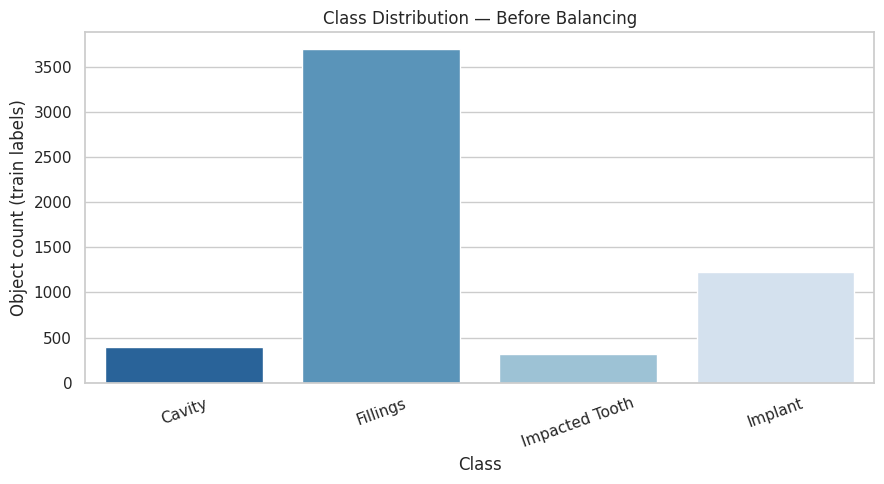

In [6]:
# ─── Distribution — Before ───────────────────────────────────────────────────
before_df = pd.DataFrame({'class': list(before_counts.keys()),
                           'count': list(before_counts.values())})

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=before_df, x='class', y='count', palette='Blues_r', ax=ax)
ax.set_title('Class Distribution — Before Balancing')
ax.set_xlabel('Class')
ax.set_ylabel('Object count (train labels)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(PROJECT_DIR / 'dist_before.png', dpi=200)
plt.show()

In [7]:
# ─── Class balancing (Virtual Oversampling) ──────────────────────────────────
# Instead of copying files to disk, we create a .txt file with duplicated paths.
# YOLO will load these paths and apply random augmentations ON-THE-FLY in memory.

def build_balanced_train_set(train_imgs, class_names, target_per_class=2000, seed=42):
    random.seed(seed)
    class_to_images = defaultdict(list)
    image_records   = []

    for img in train_imgs:
        lb      = image_to_label_path(img)
        classes = classes_in_label(lb)
        if not classes:
            continue
        image_records.append((img, lb, classes))
        for cls in classes:
            class_to_images[cls].append((img, lb, classes))

    if not image_records:
        raise RuntimeError('No labelled training images found.')

    selected = list(image_records)
    counts   = Counter()
    
    # Initial counts
    for _, lb, _ in selected:
        with open(lb, encoding='utf-8') as f:
            for ln in f:
                if ln.strip():
                    counts[int(ln.split()[0])] += 1

    # Oversample minority classes
    for _ in range(500_000):
        deficits = {c: target_per_class - counts[c] for c in range(len(class_names))}
        if all(d <= 0 for d in deficits.values()):
            break
        need_cls   = max(deficits, key=lambda c: deficits[c])
        candidates = class_to_images.get(need_cls, [])
        if not candidates:
            counts[need_cls] = target_per_class
            continue
        img, lb, _ = random.choice(candidates)
        selected.append((img, lb, classes_in_label(lb)))
        with open(lb, encoding='utf-8') as f:
            for ln in f:
                if ln.strip():
                    counts[int(ln.split()[0])] += 1

    return selected, counts

balanced_records, after_counter = build_balanced_train_set(
    train_images, class_names, TARGET_PER_CLASS, seed=42
)
after_counts = {class_names[i]: after_counter[i] for i in range(len(class_names))}
print('After counts:', after_counts)

# ─── Write path lists to disk (No image duplication!) ─────────────────────
train_txt_path = WORKDIR / 'train_balanced.txt'

# Write the virtually balanced paths to a text file
with open(train_txt_path, 'w', encoding='utf-8') as f:
    for img, lb, _ in balanced_records:
        f.write(f"{img.absolute()}\n")

# Create a new YAML that points to our .txt file for training,
# and the original absolute directories for val/test.
balanced_yaml_path = WORKDIR / 'balanced_data.yaml'
with open(balanced_yaml_path, 'w', encoding='utf-8') as f:
    yaml.safe_dump({
        'train': str(train_txt_path),
        'val':   str(val_images_dir.absolute()),
        'test':  str(test_images_dir.absolute()) if test_images_dir.exists() else str(val_images_dir.absolute()),
        'nc':    len(class_names),
        'names': class_names,
    }, f, sort_keys=False)

print('Virtual Balanced dataset txt :', train_txt_path)
print('Balanced YAML                :', balanced_yaml_path)

After counts: {'Cavity': 2001, 'Fillings': 7833, 'Impacted Tooth': 2001, 'Implant': 2663}
Virtual Balanced dataset txt : /kaggle/working/train_balanced.txt
Balanced YAML                : /kaggle/working/balanced_data.yaml


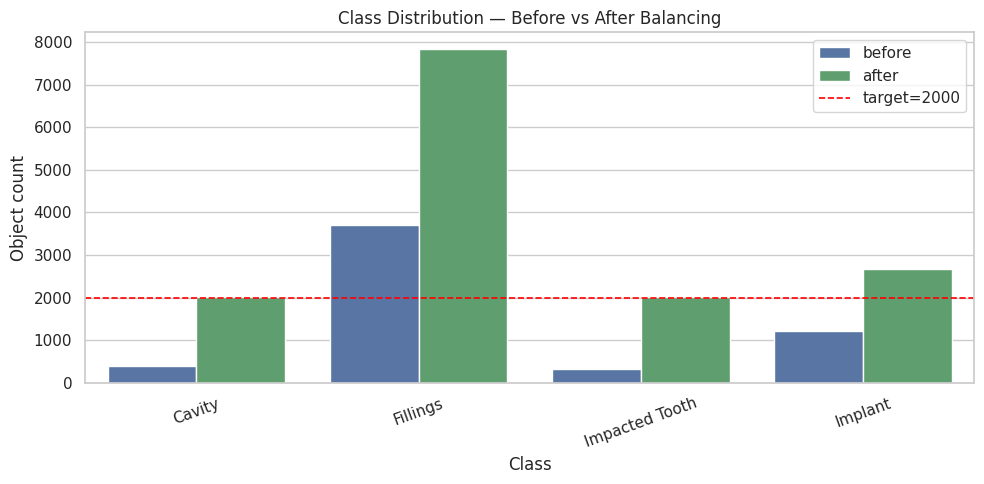

In [8]:
# ─── Distribution — After ────────────────────────────────────────────────────
after_df  = pd.DataFrame({'class': list(after_counts.keys()),
                           'count': list(after_counts.values()),
                           'stage': 'after'})
before_df2 = before_df.copy()
before_df2['stage'] = 'before'
dist_df = pd.concat([before_df2, after_df], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=dist_df, x='class', y='count',
            hue='stage', palette=['#4C72B0', '#55A868'], ax=ax)
ax.axhline(TARGET_PER_CLASS, ls='--', color='red', lw=1.2, label=f'target={TARGET_PER_CLASS}')
ax.set_title('Class Distribution — Before vs After Balancing')
ax.set_xlabel('Class')
ax.set_ylabel('Object count')
ax.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(PROJECT_DIR / 'dist_before_after.png', dpi=200)
plt.show()

In [9]:
import os

file_path = 'yolo11m.pt'
if os.path.exists(file_path):
    os.remove(file_path)
    print("✅ Corrupted yolo11m.pt file deleted!")
else:
    print("File not found in the current directory.")

File not found in the current directory.


In [10]:
# ─── Training — YOLOv8x with all improvements ────────────────────────────────
#
#  Key upgrades:
#   amp=True         → automatic mixed-precision (~2× faster on T4/P100)
#   optimizer=AdamW  → better generalisation than SGD on this task
#   cos_lr=True      → cosine annealing — avoids flat loss plateaus
#   nbs=64           → gradient accumulation (effective batch = 64)
#   warmup_epochs=5  → stable ramp-up before full LR kicks in
#   label_smoothing  → prevents over-confident predictions
#   weight_decay     → L2 regularisation
#   cache='disk'     → Kaggle SSD ≈ 3× faster epoch time
#   erasing=0.4      → random rectangular erasing (requires ultralytics>=8.1)
#   dropout=0.1      → light stochastic depth regularisation

RUN_NAME  = 'yolov11m_v2'
run_dir   = PROJECT_DIR / RUN_NAME
best_ckpt = run_dir / 'weights' / 'best.pt'
last_ckpt = run_dir / 'weights' / 'last.pt'

TRAIN_ARGS = dict(
    data          = str(balanced_yaml_path),
    epochs        = EPOCHS,
    imgsz         = IMGSZ,
    batch         = BATCH,
    device        = DEVICE,
    project       = str(PROJECT_DIR),
    name          = RUN_NAME,
    exist_ok      = True,
    patience      = PATIENCE,
    save          = True,
    save_period   = 5,           # checkpoint every 5 epochs
    pretrained    = True,
    seed          = 42,
    deterministic = True,
    workers       = 4,
    # ── precision / speed ───────────────────────────────
    amp           = True,        # mixed precision (FP16)
    cache         = 'disk',      # cache images to Kaggle SSD
    # ── optimizer & LR ──────────────────────────────────
    optimizer     = 'AdamW',
    lr0           = 0.001,       # initial LR (AdamW works best ~1e-3)
    lrf           = 0.01,        # final LR fraction (cosine)
    cos_lr        = True,        # cosine annealing schedule
    warmup_epochs = 5,
    warmup_momentum = 0.8,
    nbs           = 64,          # nominal batch → grad accum = 64/BATCH
    weight_decay  = 0.0005,
    momentum      = 0.937,
    # ── regularisation ──────────────────────────────────
    label_smoothing = 0.1,
    dropout         = 0.1,       # stochastic depth (backbone)
    # ── augmentation ────────────────────────────────────
    hsv_h         = 0.015,
    hsv_s         = 0.7,
    hsv_v         = 0.4,
    degrees       = 10.0,
    translate     = 0.1,
    scale         = 0.6,         # was 0.5
    shear         = 2.0,
    perspective   = 0.0,
    flipud        = 0.0,
    fliplr        = 0.5,
    mosaic        = 1.0,
    mixup         = 0.3,         # was 0.2
    copy_paste    = 0.2,         # was 0.1
    close_mosaic  = 15,          # was 10 — disable mosaic later in training
    erasing       = 0.4,         # random erasing (ultralytics >= 8.1)
    # ── logging & eval ──────────────────────────────────
    plots         = True,
    val           = True,
)

if last_ckpt.exists():
    print('⟳  Resuming from:', last_ckpt)
    model = YOLO(str(last_ckpt))
    model.train(resume=True)
else:
    print('▶  Starting fresh training — YOLOv11m')
    model = YOLO('yolo11m.pt')
    model.train(**TRAIN_ARGS)

print('\n── Checkpoints ───────────────────────────────')
print('best.pt :', best_ckpt)
print('last.pt :', last_ckpt)

▶  Starting fresh training — YOLOv11m
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.63 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.2, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/balanced_data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.3, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_

In [11]:
# ─── Validation — standard + Test-Time Augmentation (TTA) ────────────────────
# TTA applies flips and multi-scale inference, usually +1-3% mAP

if not best_ckpt.exists():
    raise FileNotFoundError(f'best.pt not found at {best_ckpt}')

best_model = YOLO(str(best_ckpt))

print('\n── Standard validation ───')
std_metrics = best_model.val(
    data   = str(balanced_yaml_path),
    split  = 'val',
    device = DEVICE,
    imgsz  = IMGSZ,
)

print('\n── TTA validation ───')
tta_metrics = best_model.val(
    data   = str(balanced_yaml_path),
    split  = 'val',
    device = DEVICE,
    imgsz  = IMGSZ,
    augment= True,          # ← enables TTA
)

val_summary = pd.DataFrame([
    {'mode': 'standard',
     'mAP50':    std_metrics.box.map50,
     'mAP50-95': std_metrics.box.map,
     'precision':std_metrics.box.mp,
     'recall':   std_metrics.box.mr},
    {'mode': 'TTA',
     'mAP50':    tta_metrics.box.map50,
     'mAP50-95': tta_metrics.box.map,
     'precision':tta_metrics.box.mp,
     'recall':   tta_metrics.box.mr},
])
val_summary.to_csv(PROJECT_DIR / 'val_summary.csv', index=False)
print('\n', val_summary.to_string(index=False))


── Standard validation ───
Ultralytics 8.4.63 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 126 layers, 20,033,116 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 26.0±6.2 MB/s, size: 14.2 KB)
val: Scanning /kaggle/input/datasets/kerolossoliman/dental-x-ray-yolo11/valid/labels... 215 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 215/215 505.8it/s 0.4s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/kerolossoliman/dental-x-ray-yolo11/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 3.1it/s 4.5s0.3s
                   all        215       1657      0.894      0.872      0.894      0.673
                Cavity         49        144      0.856      0.757      0.809      0.622
              Fillings        175       1074      0.917      0.931      0.955      0.682
        Impacted Tooth   

   model  best_epoch  precision  recall  mAP50  mAP50-95                                              best_ckpt                                              last_ckpt
yolov11m         131     0.9123   0.857 0.8942    0.6724 /kaggle/working/yolo11m_v2/yolov11m_v2/weights/best.pt /kaggle/working/yolo11m_v2/yolov11m_v2/weights/last.pt


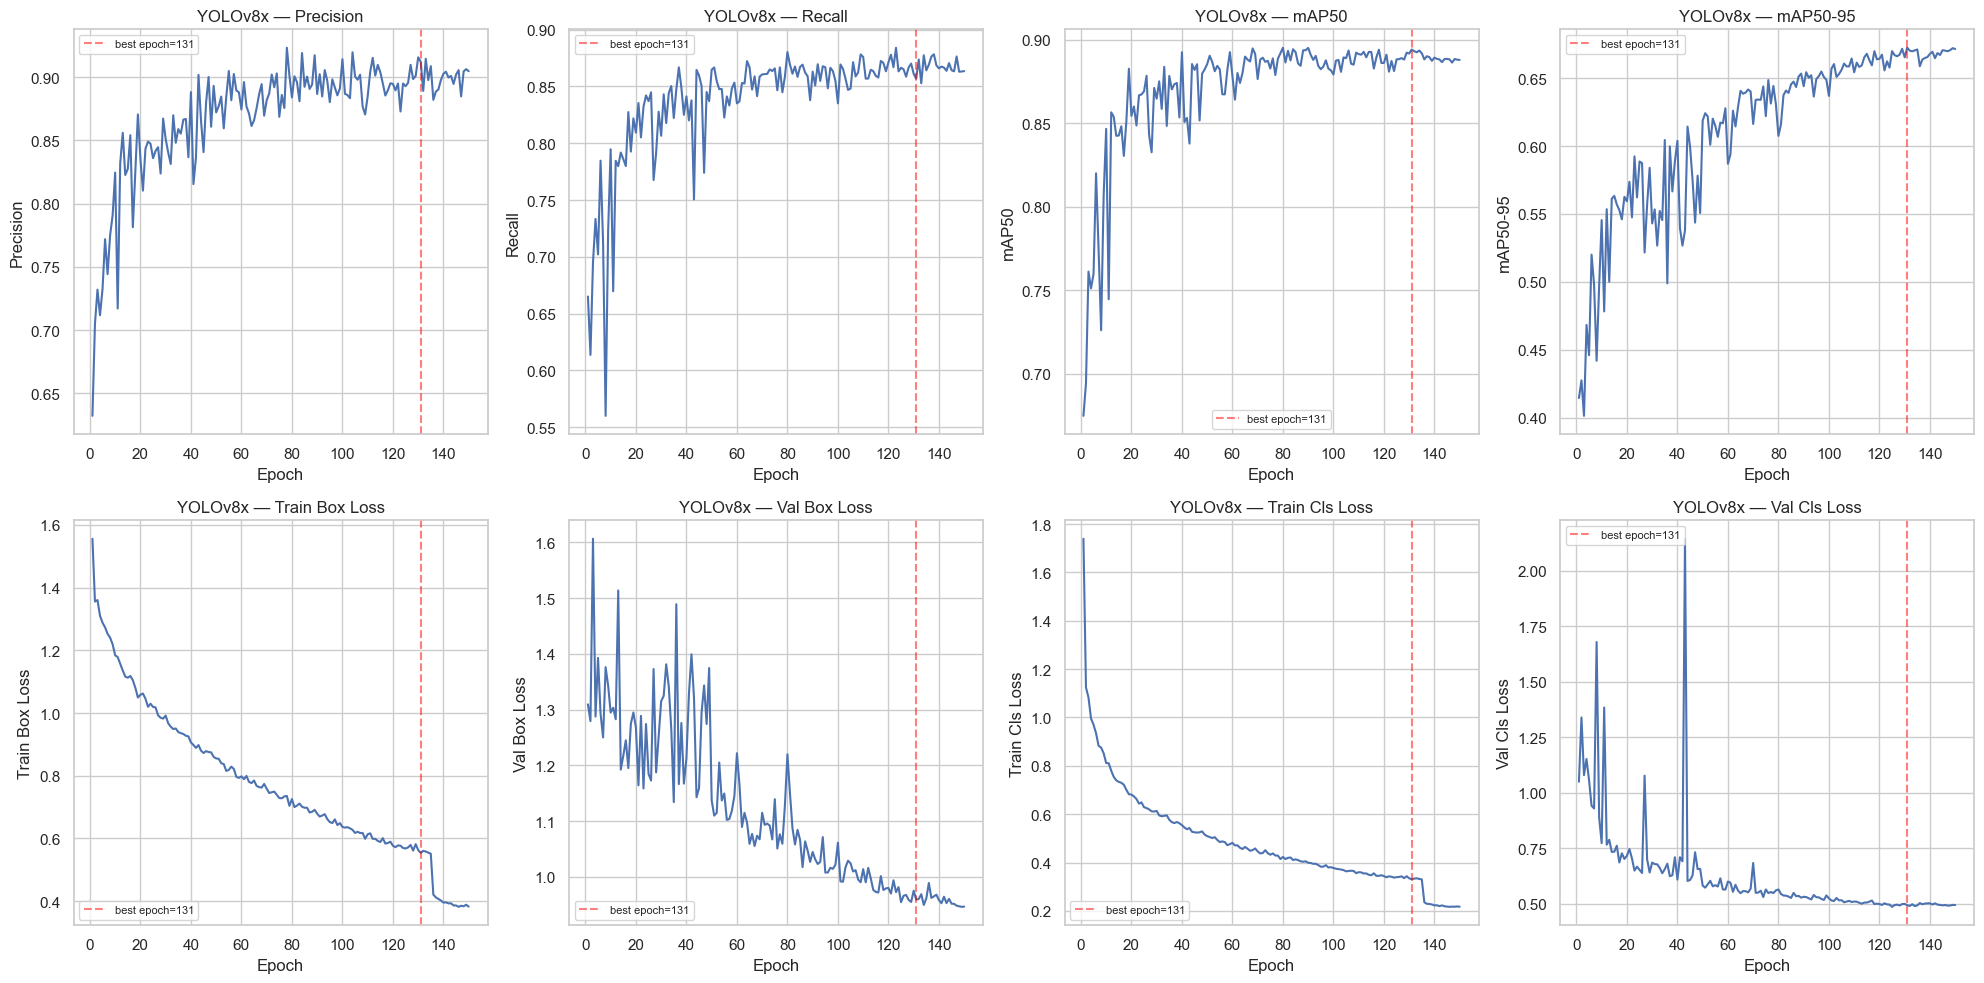

In [12]:
# ─── Metric curves ───────────────────────────────────────────────────────────
results_csv = run_dir / 'results.csv'
if not results_csv.exists():
    raise FileNotFoundError(f'results.csv not found at {results_csv}')

df = pd.read_csv(results_csv)
df.columns = [c.strip() for c in df.columns]

col_epoch = 'epoch'
col_prec  = 'metrics/precision(B)'
col_rec   = 'metrics/recall(B)'
col_map50 = 'metrics/mAP50(B)'
col_map95 = 'metrics/mAP50-95(B)'
col_tbox  = 'train/box_loss'
col_vbox  = 'val/box_loss'
col_tcls  = 'train/cls_loss'
col_vcls  = 'val/cls_loss'

best_idx  = df[col_map95].idxmax()
best_row  = df.loc[best_idx]

summary = pd.DataFrame([{
    'model':       'yolov11m',
    'best_epoch':  int(best_row[col_epoch]),
    'precision':   round(float(best_row[col_prec]),  4),
    'recall':      round(float(best_row[col_rec]),   4),
    'mAP50':       round(float(best_row[col_map50]), 4),
    'mAP50-95':    round(float(best_row[col_map95]), 4),
    'best_ckpt':   str(best_ckpt),
    'last_ckpt':   str(last_ckpt),
}])
summary.to_csv(PROJECT_DIR / 'summary.csv', index=False)
print(summary.to_string(index=False))

# 3×3 grid: precision, recall, mAP50, mAP50-95, box-loss, cls-loss
plots = [
    (col_prec,  'Precision'),
    (col_rec,   'Recall'),
    (col_map50, 'mAP50'),
    (col_map95, 'mAP50-95'),
    (col_tbox,  'Train Box Loss'),
    (col_vbox,  'Val Box Loss'),
    (col_tcls,  'Train Cls Loss'),
    (col_vcls,  'Val Cls Loss'),
]

valid_plots = [(c, t) for c, t in plots if c in df.columns]
n = len(valid_plots)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5 * nrows))
axes_flat = axes.flatten() if n > 1 else [axes]

for ax, (col, title) in zip(axes_flat, valid_plots):
    sns.lineplot(data=df, x=col_epoch, y=col, ax=ax)
    ax.axvline(int(best_row[col_epoch]), ls='--', color='red',
               alpha=0.5, label=f'best epoch={int(best_row[col_epoch])}')
    ax.set_title(f'YOLOv8x — {title}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(title)
    ax.legend(fontsize=8)

# Hide unused subplots
for ax in axes_flat[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(PROJECT_DIR / 'metric_curves.png', dpi=200)
plt.show()

Using split="test" for test evaluation.

🔍 Test evaluation — YOLOv11m  (split=test)
Ultralytics 8.4.63 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 126 layers, 20,033,116 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4.3±0.5 MB/s, size: 16.9 KB)
val: Scanning /kaggle/input/datasets/kerolossoliman/dental-x-ray-yolo11/test/labels... 107 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 107/107 238.3it/s 0.4s1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/kerolossoliman/dental-x-ray-yolo11/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.6it/s 2.7s0.4s
                   all        107        739      0.924      0.875      0.906      0.704
Speed: 1.8ms preprocess, 16.1ms inference, 0.0ms loss, 2.9ms postprocess per image
Results saved to /kaggle/working/yolo11m_v2/yolov11m_v2_test
   mAP@0.5

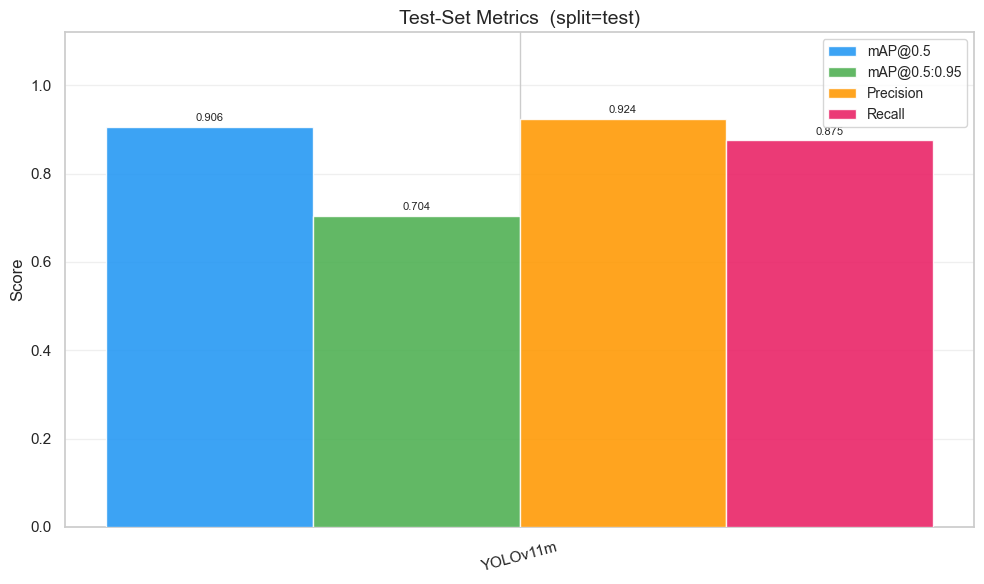

✅ Saved: /kaggle/working/yolo11m_v2/test_metrics_bar.png


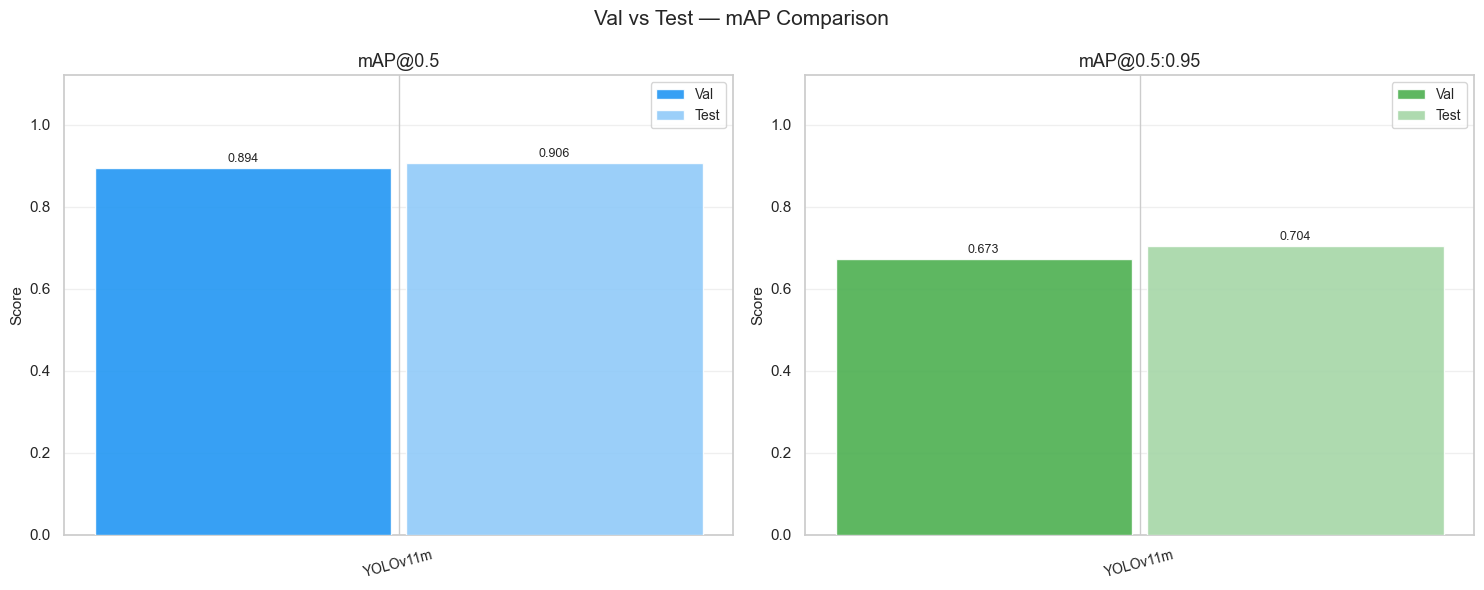

✅ Saved: /kaggle/working/yolo11m_v2/val_vs_test_comparison.png


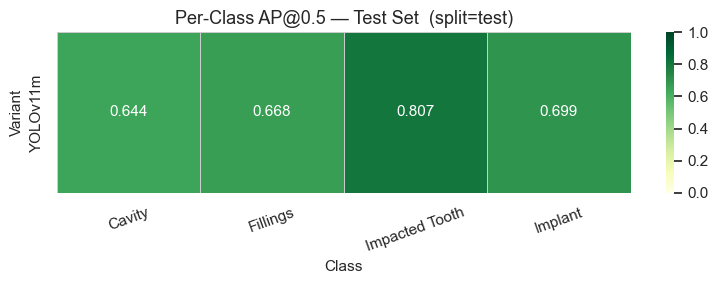

✅ Saved: /kaggle/working/yolo11m_v2/test_per_class_ap_heatmap.png


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 6b: Test-set evaluation — mAP@0.5, mAP@0.5:0.95, Precision, Recall
#           + per-class AP breakdown + Val vs Test comparison chart
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from pathlib import Path
from ultralytics import YOLO

# ── Resolve test split from balanced_data.yaml ───────────────────────────────
with open(balanced_yaml_path) as f:
    _dy = yaml.safe_load(f)

_split = 'test' if _dy.get('test') else 'val'
print(f'Using split="{_split}" for test evaluation.')

# ── Run test evaluation ───────────────────────────────────────────────────────
test_rows     = []
test_perclass = {}

variant_name = 'YOLOv11m'
run_name     = RUN_NAME
best_weights = run_dir / 'weights' / 'best.pt'

if not best_weights.exists():
    print(f'⚠️  best.pt not found at {best_weights}')
else:
    print(f'\n🔍 Test evaluation — {variant_name}  (split={_split})')
    model = YOLO(str(best_weights))

    test_results = model.val(
        data     = str(balanced_yaml_path),
        split    = _split,
        imgsz    = IMGSZ,
        batch    = BATCH,
        device   = DEVICE,
        project  = str(PROJECT_DIR),
        name     = f'{run_name}_test',
        exist_ok = True,
        verbose  = False,
    )

    rd = test_results.results_dict if hasattr(test_results, 'results_dict') else {}

    map50   = round(rd.get('metrics/mAP50(B)',    0), 4)
    map5095 = round(rd.get('metrics/mAP50-95(B)', 0), 4)
    prec    = round(rd.get('metrics/precision(B)', 0), 4)
    rec     = round(rd.get('metrics/recall(B)',    0), 4)

    print(f'   mAP@0.5={map50:.4f}  mAP@0.5:0.95={map5095:.4f}  '
          f'Precision={prec:.4f}  Recall={rec:.4f}')

    test_rows.append({
        'Variant':      variant_name,
        'mAP@0.5':      map50,
        'mAP@0.5:0.95': map5095,
        'Precision':    prec,
        'Recall':       rec,
        'Split':        _split,
    })

    try:
        test_perclass[variant_name] = list(test_results.box.maps)
    except Exception:
        test_perclass[variant_name] = [0.0] * len(class_names)

test_df = pd.DataFrame(test_rows)

# Save CSV
test_csv = PROJECT_DIR / 'test_metrics.csv'
test_df.to_csv(test_csv, index=False)
print(f'\n✅ Test metrics saved → {test_csv}')
print('\n' + '═'*65)
print(f'  📋 Test Metrics (split={_split})')
print('═'*65)
print(test_df[['Variant','mAP@0.5','mAP@0.5:0.95','Precision','Recall']].to_string(index=False))

# ── Figure 1: Test metrics bar chart ─────────────────────────────────────────
COLORS   = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
variants = test_df['Variant'].tolist()
x = np.arange(len(variants))
w = 0.2

fig, ax = plt.subplots(figsize=(max(10, len(variants) * 2.5), 6))
metrics_plot = ['mAP@0.5', 'mAP@0.5:0.95', 'Precision', 'Recall']
offsets      = [-1.5, -0.5, 0.5, 1.5]

for metric, offset, color in zip(metrics_plot, offsets, COLORS):
    bars = ax.bar(x + offset * w, test_df[metric], w,
                  label=metric, color=color, alpha=0.88, zorder=3)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.008,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(variants, rotation=15, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_title(f'Test-Set Metrics  (split={_split})', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
out1 = PROJECT_DIR / 'test_metrics_bar.png'
plt.savefig(out1, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {out1}')

# ── Figure 2: Val vs Test comparison ─────────────────────────────────────────
# Build a val metrics row from val_summary (standard mode)
if 'val_summary' in dir() and not val_summary.empty:
    std_row = val_summary[val_summary['mode'] == 'standard'].iloc[0]
    metrics_df_v11 = pd.DataFrame([{
        'Variant':      variant_name,
        'mAP@0.5':      round(float(std_row['mAP50']),    4),
        'mAP@0.5:0.95': round(float(std_row['mAP50-95']), 4),
        'Precision':    round(float(std_row['precision']), 4),
        'Recall':       round(float(std_row['recall']),    4),
    }])

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    compare_metrics = ['mAP@0.5', 'mAP@0.5:0.95']
    pair_colors     = [('#2196F3', '#90CAF9'), ('#4CAF50', '#A5D6A7')]

    for ax, metric, (c_val, c_test) in zip(axes, compare_metrics, pair_colors):
        val_scores  = metrics_df_v11.set_index('Variant')[metric].reindex(variants).fillna(0)
        test_scores = test_df.set_index('Variant')[metric].reindex(variants).fillna(0)

        bv = ax.bar(x - 0.2, val_scores,  0.38, label='Val',  color=c_val,  alpha=0.9, zorder=3)
        bt = ax.bar(x + 0.2, test_scores, 0.38, label='Test', color=c_test, alpha=0.9, zorder=3)

        for bar in list(bv) + list(bt):
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.008,
                    f'{h:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

        ax.set_xticks(x)
        ax.set_xticklabels(variants, rotation=15, fontsize=10)
        ax.set_ylim(0, 1.12)
        ax.set_title(metric, fontsize=13, fontweight='bold')
        ax.set_ylabel('Score', fontsize=11)
        ax.legend(fontsize=10)
        ax.grid(axis='y', alpha=0.3, zorder=0)
        ax.set_axisbelow(True)

    fig.suptitle('Val vs Test — mAP Comparison', fontsize=15, fontweight='bold')
    plt.tight_layout()
    out2 = PROJECT_DIR / 'val_vs_test_comparison.png'
    plt.savefig(out2, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: {out2}')
else:
    print('ℹ️  val_summary not available — skipping Val vs Test chart.')

# ── Figure 3: Per-class AP@0.5 heatmap ───────────────────────────────────────
if test_perclass:
    hm_data     = np.array([test_perclass[v] for v in variants if v in test_perclass])
    hm_variants = [v for v in variants if v in test_perclass]

    fig, ax = plt.subplots(figsize=(max(8, len(class_names) * 2), max(3, len(hm_variants) * 1.2 + 1)))
    sns.heatmap(
        hm_data,
        annot=True, fmt='.3f', cmap='YlGn',
        xticklabels=class_names,
        yticklabels=hm_variants,
        vmin=0, vmax=1, ax=ax,
        linewidths=0.5, linecolor='#cccccc',
        annot_kws={'size': 11, 'weight': 'bold'},
    )
    ax.set_title(f'Per-Class AP@0.5 — Test Set  (split={_split})',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Class',   fontsize=11)
    ax.set_ylabel('Variant', fontsize=11)
    ax.tick_params(axis='x', rotation=20)
    plt.tight_layout()
    out3 = PROJECT_DIR / 'test_per_class_ap_heatmap.png'
    plt.savefig(out3, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: {out3}')

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 6c: Test-set curves — per-class AND all-in-one
#
#  Figure A — Per-class subplots (one per class):
#             Each metric (Precision / Recall / mAP@0.5) gets its own
#             distinct color so the three lines are clearly separable.
#
#  Figure B — All-classes all-in-one overlay:
#             Class = color (same as before).
#             Metric = line style + marker + alpha layer so every
#             combination is visually unique even when lines overlap.
# ─────────────────────────────────────────────────────────────────────────────
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from pathlib import Path
from ultralytics import YOLO
import yaml

# ── Resolve test split ────────────────────────────────────────────────────────
with open(balanced_yaml_path) as _f:
    _dy = yaml.safe_load(_f)
_split = 'test' if _dy.get('test') else 'val'
print(f'Using split="{_split}" for test curves.')

# ── Color/style maps ──────────────────────────────────────────────────────────
# Figure A: each *metric* gets its own color (class is already the subplot title)
METRIC_COLORS = {
    'Precision': '#2196F3',   # blue
    'Recall':    '#4CAF50',   # green
    'mAP@0.5':  '#E91E63',   # pink/red
}

# Figure B: each *class* gets its color; metrics differ by line+marker+alpha
CLASS_COLORS_6c = {
    'cavity':   '#E91E63',
    'filling':  '#2196F3',
    'impacted': '#FF9800',
    'implant':  '#4CAF50',
}
# (linestyle, marker, linewidth, markersize, alpha)
METRIC_STYLES_6c = {
    'Precision': ('-',   'o', 2.2, 7,  0.95),
    'Recall':    ('--',  's', 2.2, 7,  0.80),
    'mAP@0.5':  (':',   '^', 2.6, 9,  0.95),
}

weights_dir = run_dir / 'weights'
if not weights_dir.exists():
    print(f'⚠️  weights dir not found at {weights_dir}')
else:
    # Collect epoch checkpoints + best.pt
    ckpt_files = sorted(
        weights_dir.glob('epoch*.pt'),
        key=lambda p: int(re.search(r'epoch(\d+)', p.stem).group(1))
    )
    best_pt = weights_dir / 'best.pt'
    if best_pt.exists() and best_pt not in ckpt_files:
        ckpt_files.append(best_pt)

    if not ckpt_files:
        print('⚠️  No epoch checkpoints found — falling back to best.pt only.')
        ckpt_files = [best_pt] if best_pt.exists() else []

    if ckpt_files:
        classes      = class_names
        nc           = len(classes)
        epoch_labels = []
        data_6c      = {cls: {'Precision': [], 'Recall': [], 'mAP@0.5': []} for cls in classes}

        print(f'\n🔍 {RUN_NAME}: scanning {len(ckpt_files)} checkpoint(s) on split="{_split}"…')

        for ckpt in ckpt_files:
            ep_match = re.search(r'epoch(\d+)', ckpt.stem)
            epoch_labels.append(int(ep_match.group(1)) if ep_match else 'best')

            m  = YOLO(str(ckpt))
            vr = m.val(
                data     = str(balanced_yaml_path),
                split    = _split,
                imgsz    = IMGSZ,
                batch    = BATCH,
                device   = DEVICE,
                project  = str(PROJECT_DIR),
                name     = f'{RUN_NAME}_6c_val',
                exist_ok = True,
                verbose  = False,
            )
            try:
                ap_idx  = list(vr.box.ap_class_index)
                ap_v    = list(vr.box.ap)
                p_v     = list(vr.box.p)
                r_v     = list(vr.box.r)
                idx_map = {idx: pos for pos, idx in enumerate(ap_idx)}
                for ci, cls in enumerate(classes):
                    pos = idx_map.get(ci)
                    data_6c[cls]['Precision'].append(p_v[pos]  if pos is not None else 0.0)
                    data_6c[cls]['Recall'].append(   r_v[pos]  if pos is not None else 0.0)
                    data_6c[cls]['mAP@0.5'].append(  ap_v[pos] if pos is not None else 0.0)
            except Exception as e:
                print(f'   ⚠️  Could not extract metrics from {ckpt.name}: {e}')
                for cls in classes:
                    data_6c[cls]['Precision'].append(0.0)
                    data_6c[cls]['Recall'].append(0.0)
                    data_6c[cls]['mAP@0.5'].append(0.0)

        x       = list(range(len(epoch_labels)))
        x_ticks = [str(e) for e in epoch_labels]

        # ─────────────────────────────────────────────────────────────────────
        # Figure A: Per-class subplots
        # Each metric line has its own color — class is identified by the title.
        # ─────────────────────────────────────────────────────────────────────
        fig_a, axes_a = plt.subplots(nc, 1, figsize=(14, 4.8 * nc), sharey=False)
        if nc == 1:
            axes_a = [axes_a]

        for ax, cls in zip(axes_a, classes):
            cls_color = CLASS_COLORS_6c.get(cls, '#333333')

            for metric, (ls, marker, lw, ms, al) in METRIC_STYLES_6c.items():
                m_color = METRIC_COLORS[metric]
                vals    = data_6c[cls][metric]
                if not vals:
                    continue
                ax.plot(x, vals,
                        ls=ls, marker=marker, color=m_color,
                        lw=lw, markersize=ms, alpha=al,
                        label=f'{metric}  (peak={max(vals):.3f})')
                # Highlight the peak point with the class color ring
                best_i = int(np.argmax(vals))
                ax.scatter(x[best_i], vals[best_i],
                           s=90, zorder=7,
                           facecolors=m_color, edgecolors=cls_color,
                           linewidths=2.5)

            # Shade subplot background lightly with the class color
            ax.set_facecolor(cls_color + '0D')   # 5 % opacity hex suffix

            ax.set_title(f'{cls.capitalize()}', fontsize=13, fontweight='bold',
                         color=cls_color)
            ax.set_xticks(x)
            ax.set_xticklabels(x_ticks, rotation=45, fontsize=8)
            ax.set_xlabel('Epoch / Checkpoint', fontsize=9)
            ax.set_ylabel('Score', fontsize=9)
            ax.set_ylim(0, 1.05)
            ax.legend(fontsize=9, loc='lower right')
            ax.grid(alpha=0.28)

        fig_a.suptitle(
            f'YOLOv11m — Per-Class Test Curves  (split={_split})',
            fontsize=15, fontweight='bold'
        )
        plt.tight_layout()
        out_a = PROJECT_DIR / f'{RUN_NAME}_test_per_class_curves.png'
        plt.savefig(out_a, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'✅ Saved: {out_a}')

        # ─────────────────────────────────────────────────────────────────────
        # Figure B: All-classes all-in-one overlay
        # Class = solid color.  Metric = linestyle + marker + size + alpha.
        # Every (class × metric) combo is visually unique.
        # ─────────────────────────────────────────────────────────────────────
        fig_b, ax_b = plt.subplots(figsize=(16, 8))

        for cls in classes:
            cls_color = CLASS_COLORS_6c.get(cls, '#333333')
            for metric, (ls, marker, lw, ms, al) in METRIC_STYLES_6c.items():
                vals = data_6c[cls][metric]
                if not vals:
                    continue
                ax_b.plot(x, vals,
                          ls=ls, marker=marker,
                          color=cls_color,
                          lw=lw, markersize=ms, alpha=al)
                # Mark the peak with a contrasting ring
                best_i = int(np.argmax(vals))
                ax_b.scatter(x[best_i], vals[best_i],
                             s=80, zorder=7,
                             facecolors=cls_color,
                             edgecolors='white', linewidths=1.8)

        ax_b.set_xticks(x)
        ax_b.set_xticklabels(x_ticks, rotation=45, fontsize=9)
        ax_b.set_xlabel('Epoch / Checkpoint', fontsize=12)
        ax_b.set_ylabel('Score', fontsize=12)
        ax_b.set_ylim(0, 1.05)
        ax_b.set_title(
            f'YOLOv11m — All Classes × All Metrics  Test Curves  (split={_split})',
            fontsize=14, fontweight='bold'
        )
        ax_b.grid(alpha=0.22)

        # Two-level legend: class (color swatch) + metric (linestyle key)
        class_handles = [
            mlines.Line2D([], [], color=CLASS_COLORS_6c.get(c, '#333'),
                          lw=3, label=c.capitalize())
            for c in classes
        ]
        metric_handles = [
            mlines.Line2D([], [], color='#555555',
                          ls=ls, marker=mk, lw=lw, markersize=ms,
                          alpha=al, label=m)
            for m, (ls, mk, lw, ms, al) in METRIC_STYLES_6c.items()
        ]
        leg1 = ax_b.legend(handles=class_handles,
                            title='Class',  title_fontsize=10,
                            loc='upper left',  fontsize=10,
                            framealpha=0.9)
        leg2 = ax_b.legend(handles=metric_handles,
                            title='Metric', title_fontsize=10,
                            loc='lower right', fontsize=10,
                            framealpha=0.9)
        ax_b.add_artist(leg1)   # keep both legends visible

        plt.tight_layout()
        out_b = PROJECT_DIR / f'{RUN_NAME}_test_all_classes_curves.png'
        plt.savefig(out_b, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'✅ Saved: {out_b}')

In [13]:
# ─── Export best model to ONNX ───────────────────────────────────────────────
# ONNX is portable: run on CPU, TensorRT, OpenVINO, mobile, etc.

print('Exporting best.pt → ONNX …')
export_model = YOLO(str(best_ckpt))
onnx_path = export_model.export(
    format  = 'onnx',
    imgsz   = IMGSZ,
    dynamic = True,    # dynamic batch axis
    simplify= True,    # onnx-simplifier: smaller + faster
    opset   = 17,
)
print('ONNX saved to:', onnx_path)

Exporting best.pt → ONNX …
Ultralytics 8.4.63 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11m summary (fused): 126 layers, 20,033,116 parameters, 0 gradients, 67.7 GFLOPs

PyTorch: starting from '/kaggle/working/yolo11m_v2/yolov11m_v2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 8, 8400) (38.6 MB)
requirements: Ultralytics requirements ['onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 303ms
Prepared 2 packages in 332ms
Installed 2 packages in 9ms
 + onnxruntime==1.26.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 1.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 17...
ONNX: slimming with onnxslim 0.1.94

In [14]:
# ─── Final manifest ──────────────────────────────────────────────────────────
manifest = {
    'data_yaml_original' : str(data_yaml_path),
    'data_yaml_balanced' : str(balanced_yaml_path),
    'project_dir'        : str(PROJECT_DIR),
    'model'              : 'yolov8x.pt',
    'target_per_class'   : TARGET_PER_CLASS,
    'epochs'             : EPOCHS,
    'imgsz'              : IMGSZ,
    'batch'              : BATCH,
    'nbs'                : NBS,
    'optimizer'          : 'AdamW',
    'amp'                : True,
    'cos_lr'             : True,
    'best_checkpoint'    : str(best_ckpt),
    'last_checkpoint'    : str(last_ckpt),
}
with open(PROJECT_DIR / 'run_manifest.yaml', 'w', encoding='utf-8') as f:
    yaml.safe_dump(manifest, f, sort_keys=False)

print('─' * 52)
print('All artifacts saved to:', PROJECT_DIR)
print('Re-run training cell to auto-resume on runtime restart.')
print('─' * 52)

────────────────────────────────────────────────────
All artifacts saved to: /kaggle/working/yolo11m_v2
Re-run training cell to auto-resume on runtime restart.
────────────────────────────────────────────────────


In [15]:
!pip install -q pydrive

import shutil
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive

DATASET_PATH = '/kaggle/input/datasets/kerolossoliman/kaggle-output-downloader'

# Copy BOTH files to working dir (writable)
shutil.copy(f'{DATASET_PATH}/client_secrets.json', '/kaggle/working/client_secrets.json')
shutil.copy(f'{DATASET_PATH}/gdrive.json',         '/kaggle/working/gdrive.json')

os.chdir('/kaggle/working')   # make sure PyDrive finds client_secrets.json

gauth = GoogleAuth()
gauth.LoadCredentialsFile('/kaggle/working/gdrive.json')  # ← load from writable path

if gauth.credentials is None or gauth.access_token_expired:
    gauth.Refresh()
else:
    gauth.Authorize()

drive = GoogleDrive(gauth)
print('✅ Authenticated')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 987.4/987.4 kB 14.9 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done


RefreshError: Access token refresh failed: invalid_grant: Bad Request

In [ ]:
!pip install -q google-api-python-client google-auth google-auth-httplib2 requests tqdm

import os
import zipfile
import requests
from tqdm.auto import tqdm
from google.oauth2.credentials import Credentials
from googleapiclient.discovery import build
from googleapiclient.http import MediaFileUpload
import google.auth.transport.requests

FOLDER_ID = '1UZ8MkXMnGeiC1WRKtwQARos'

# ── Rebuild service using credentials from existing gauth ─────────────────────
creds_data = gauth.credentials

creds = Credentials(
    token         = creds_data.access_token,
    refresh_token = creds_data.refresh_token,
    token_uri     = 'https://oauth2.googleapis.com/token',
    client_id     = creds_data.client_id,
    client_secret = creds_data.client_secret,
)

# Refresh if expired
if creds.expired:
    creds.refresh(google.auth.transport.requests.Request())

service = build('drive', 'v2', credentials=creds)

# ── Step 1: Zip with progress bar ─────────────────────────────────────────────
zip_path    = '/kaggle/working/yolov11xl_results.zip'
folder_path = '/kaggle/working/yolov8xl_v2'

all_files = []
for root, dirs, files in os.walk(folder_path):
    for file in files:
        all_files.append(os.path.join(root, file))

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    with tqdm(total=len(all_files), desc='📦 Zipping', unit='file') as pbar:
        for file_path in all_files:
            arcname = os.path.relpath(file_path, folder_path)
            zf.write(file_path, arcname)
            pbar.set_postfix(file=os.path.basename(file_path)[:30])
            pbar.update(1)

zip_size = os.path.getsize(zip_path) / (1024 ** 2)
print(f'✅ Zip done — {zip_size:.1f} MB')

# ── Step 2: Upload with progress bar ──────────────────────────────────────────
file_size  = os.path.getsize(zip_path)
chunk_size = 5 * 1024 * 1024   # 5 MB chunks

media = MediaFileUpload(
    zip_path,
    mimetype  = 'application/zip',
    chunksize = chunk_size,
    resumable = True,
)

metadata = {
    'title':   'yolov11xl_results.zip',
    'parents': [{'id': FOLDER_ID}],
}

request = service.files().insert(body=metadata, media_body=media)

with tqdm(total=file_size, desc='🚀 Uploading', unit='B',
          unit_scale=True, unit_divisor=1024) as pbar:
    response = None
    prev     = 0
    while response is None:
        status, response = request.next_chunk()
        if status:
            pbar.update(int(status.resumable_progress) - prev)
            prev = int(status.resumable_progress)
    pbar.n = file_size
    pbar.refresh()

file_id = response.get('id')
print(f'✅ Uploaded — yolov11xl_results.zip')
print(f'   🔗 https://drive.google.com/file/d/{file_id}/view')